In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from datetime import datetime
from statsmodels.tsa.stattools import adfuller

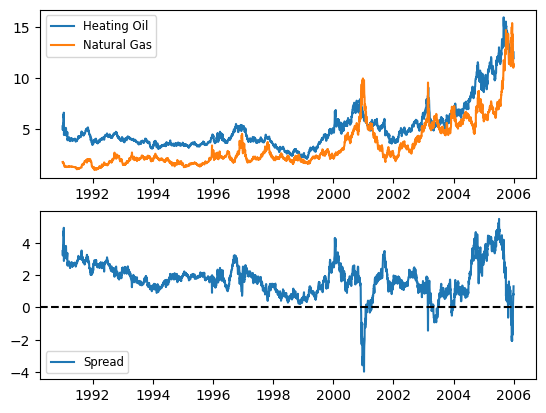

In [2]:
HO = pd.read_csv('../Data/time_series/CME_HO.csv', parse_dates = ['Date'], index_col = 'Date')
NG = pd.read_csv('../Data/time_series/CME_NG.csv', parse_dates = ['Date'], index_col = 'Date')

HO = HO.sort_index(ascending = True)
NG = NG.sort_index(ascending = True)

# Plot the prices separately
plt.subplot(2, 1, 1)
plt.plot(7.25 * HO, label = 'Heating Oil')
plt.plot(NG, label = 'Natural Gas')
plt.legend(loc = 'best', fontsize = 'small')

# Plot the spread
plt.subplot(2, 1, 2)
plt.plot(7.25 * HO - NG, label = 'Spread')
plt.legend(loc = 'best', fontsize = 'small')
plt.axhline(y = 0, linestyle = '--', color = 'k')
plt.show()

In [3]:
HO = pd.read_csv('../Data/time_series/CME_HO.csv', parse_dates = ['Date'], index_col = 'Date')
NG = pd.read_csv('../Data/time_series/CME_NG.csv', parse_dates = ['Date'], index_col = 'Date')

HO = HO.sort_index(ascending = True)
NG = NG.sort_index(ascending = True)

# Compute the ADF for HO and NG
result_HO = adfuller(HO['Close'])
print("The p-value for the ADF test on HO is ", result_HO[1])

result_NG = adfuller(NG['Close'])
print("The p-value for the ADF test on NG is ", result_NG[1])

# Compute the ADF of the spread
result_spread = adfuller(7.25 * HO - NG)
print("The p-value for the ADF test on the spread is ", result_spread[1])

The p-value for the ADF test on HO is  0.9567108785017873
The p-value for the ADF test on NG is  0.900874744467673
The p-value for the ADF test on the spread is  7.019439302142211e-05


In [4]:
def parse_date(text):
    for fmt in ('%m/%d/%Y', '%m-%d-%y'):
        try:
            return datetime.strptime(text, fmt)
        except ValueError:
            continue
        raise ValueError('No valid date format found')

BTC = pd.read_csv('../Data/time_series/Bitcoin.csv', usecols = [0, 1])
ETH = pd.read_csv('../Data/time_series/Ethereum.csv', usecols = [0, 1])

BTC['Date'] = BTC['Date'].apply(parse_date)
ETH['Date'] = ETH['Date'].apply(parse_date)

BTC.set_index('Date', inplace = True)
ETH.set_index('Date', inplace = True)

BTC = BTC.sort_index(ascending = True)
ETH = ETH.sort_index(ascending = True)

BTC['Price'] = BTC['Price'].str.replace(r"[',]", '', regex = True).astype(float)
ETH['Price'] = ETH['Price'].str.replace(r"[',]", '', regex = True).astype(float)

# Regress BTC on ETH
ETH = sm.add_constant(ETH)
result = sm.OLS(BTC, ETH).fit()

# Compute ADF
b = result.params['Price']
adf_stats = adfuller(BTC['Price'] - b * ETH['Price'])
print("The p-value for the ADF test is ", adf_stats[1])

The p-value for the ADF test is  0.21466669957736023
